# Projeto da Disciplina: Sprint: Qualidade de Software, Segurança e Sistemas Inteligentes

---
**Aluna:** Luciana Coda Sant'Anna Gomes
---

## 1. O Problema de Negócio e os Dados
### O Desafio
Instituições financeiras lidam diariamente com o desafio de separar bons de maus pagadores antes de conceder crédito. Errar nessa decisão custa caro. Abordagens antigas, baseadas em regras fixas, já não dão conta de analisar a complexidade do comportamento humano. É aqui que o Machine Learning entra.

### Nossa Base de Dados
* **Origem:** Utilizamos o dataset oficial `default-of-credit-card-clients-dataset` da UCI (via Kaggle).
* **Tamanho:** 30.000 clientes e 24 features.
* **Nosso Alvo:** A variável `default.payment.next.month` (1 = Calote, 0 = Em dia).
* **O Problema Técnico:** Classificação Binária.

In [1]:
# Configuração inicial e verificação de dependências
import os
import sys

if os.path.exists('requirements.txt'):
    !{sys.executable} -m pip install --upgrade pip -q && pip install -r requirements.txt -q
    print("Bibliotecas de ambiente prontas.")

In [2]:
# Importação das Bibliotecas
import stat
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

# Configurações Globais
RANDOM_STATE = 42
N_JOBS = -1
CV_FOLDS = 5

%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Preparando o Terreno (Carga e Limpeza)
Baixando os dados da fonte e limpando dados irrelevantes ou sensíveis.

In [3]:
# Download e Carga dos Dados
DATA_DIR = 'data'
DATA_FILE = 'UCI_Credit_Card.csv'
DATA_PATH = os.path.join(DATA_DIR, DATA_FILE)
KAGGLE_FILE = 'kaggle.json'

if os.path.exists(KAGGLE_FILE):
    os.chmod(KAGGLE_FILE, stat.S_IRUSR | stat.S_IWUSR)

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
    !kaggle datasets download -d uciml/default-of-credit-card-clients-dataset -p data --unzip --force > /dev/null 2>&1
    print("Dataset baixado com sucesso.")

df = pd.read_csv(DATA_PATH)
df.rename(columns={'default.payment.next.month': 'target'}, inplace=True)


# TÉCNICA DE ANONIMIZAÇÃO: Supressão de Identificadores (Anonymization)
# Conforme boas práticas de segurança, removemos o ID para mitigar o
# risco de identificação direta (inferência explícita) do titular.
# Isso garante a privacidade (LGPD) sem impactar a utilidade do modelo preditivo,
# mitigando o risco de reidentificação em caso de vazamento da base.
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)


X = df.drop('target', axis=1)
y = df['target']
print(f"Dados prontos: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset baixado com sucesso.
Dados prontos: 30000 linhas e 24 colunas.


## 3. Separação entre Treino e Teste (Holdout)
A separação holdout deve ocorrer estritamente antes das transformações.

In [4]:
# Holdout com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 24000 amostras | Teste: 6000 amostras


## 4. Transformação, Modelagem e Otimização de Hiperparâmetros
Uso de Pipelines para evitar data leakage durante o cross-validation.

In [5]:
# Definição dos Pipelines e Hiperparâmetros
pipelines = {
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'Arvore_Classificacao': Pipeline([('scaler', MinMaxScaler()), ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    'Naive_Bayes': Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=RANDOM_STATE))])
}

param_grids = {
    'KNN': {'clf__n_neighbors': [3, 5, 7]},
    'Arvore_Classificacao': {'clf__max_depth': [5, 10, None], 'clf__min_samples_split': [2, 5]},
    'Naive_Bayes': {'clf__var_smoothing': [1e-9, 1e-8]},
    'SVM': {'clf__C': [0.1, 1], 'clf__kernel': ['linear', 'rbf']}
}

Executando o treinamento com Grid Search e Cross-Validation:

In [6]:
best_models = {}
resultados = []

for model_name in pipelines:
    print(f'Treinando e otimizando: {model_name}...')
    grid = GridSearchCV(
        pipelines[model_name], param_grids[model_name], cv=CV_FOLDS, scoring='f1', n_jobs=N_JOBS
    )
    grid.fit(X_train, y_train)
    best_models[model_name] = grid.best_estimator_

    y_pred = grid.predict(X_test)

    resultados.append({
        'Modelo': model_name,
        'Melhores Parametros': str(grid.best_params_),
        'Acuracia': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Precisao': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })
print('\nTreinamento concluído!')

Treinando e otimizando: KNN...
Treinando e otimizando: Arvore_Classificacao...
Treinando e otimizando: Naive_Bayes...
Treinando e otimizando: SVM...

Treinamento concluído!


## 5. Avaliação e Comparação de Resultados

,Modelo,Melhores Parametros,Acuracia,F1-Score,Precisao,Recall
2,Naive_Bayes,{'clf__var_smoothing': 1e-09},0.752500,0.497462,0.451474,0.553881
1,Arvore_Classificacao,"{'clf__max_depth': 10, 'clf__min_samples_split...",0.809667,0.450962,0.622842,0.353429
3,SVM,"{'clf__C': 1, 'clf__kernel': 'rbf'}",0.816000,0.448551,0.665185,0.338357
0,KNN,{'clf__n_neighbors': 7},0.800333,0.433302,0.581957,0.345139


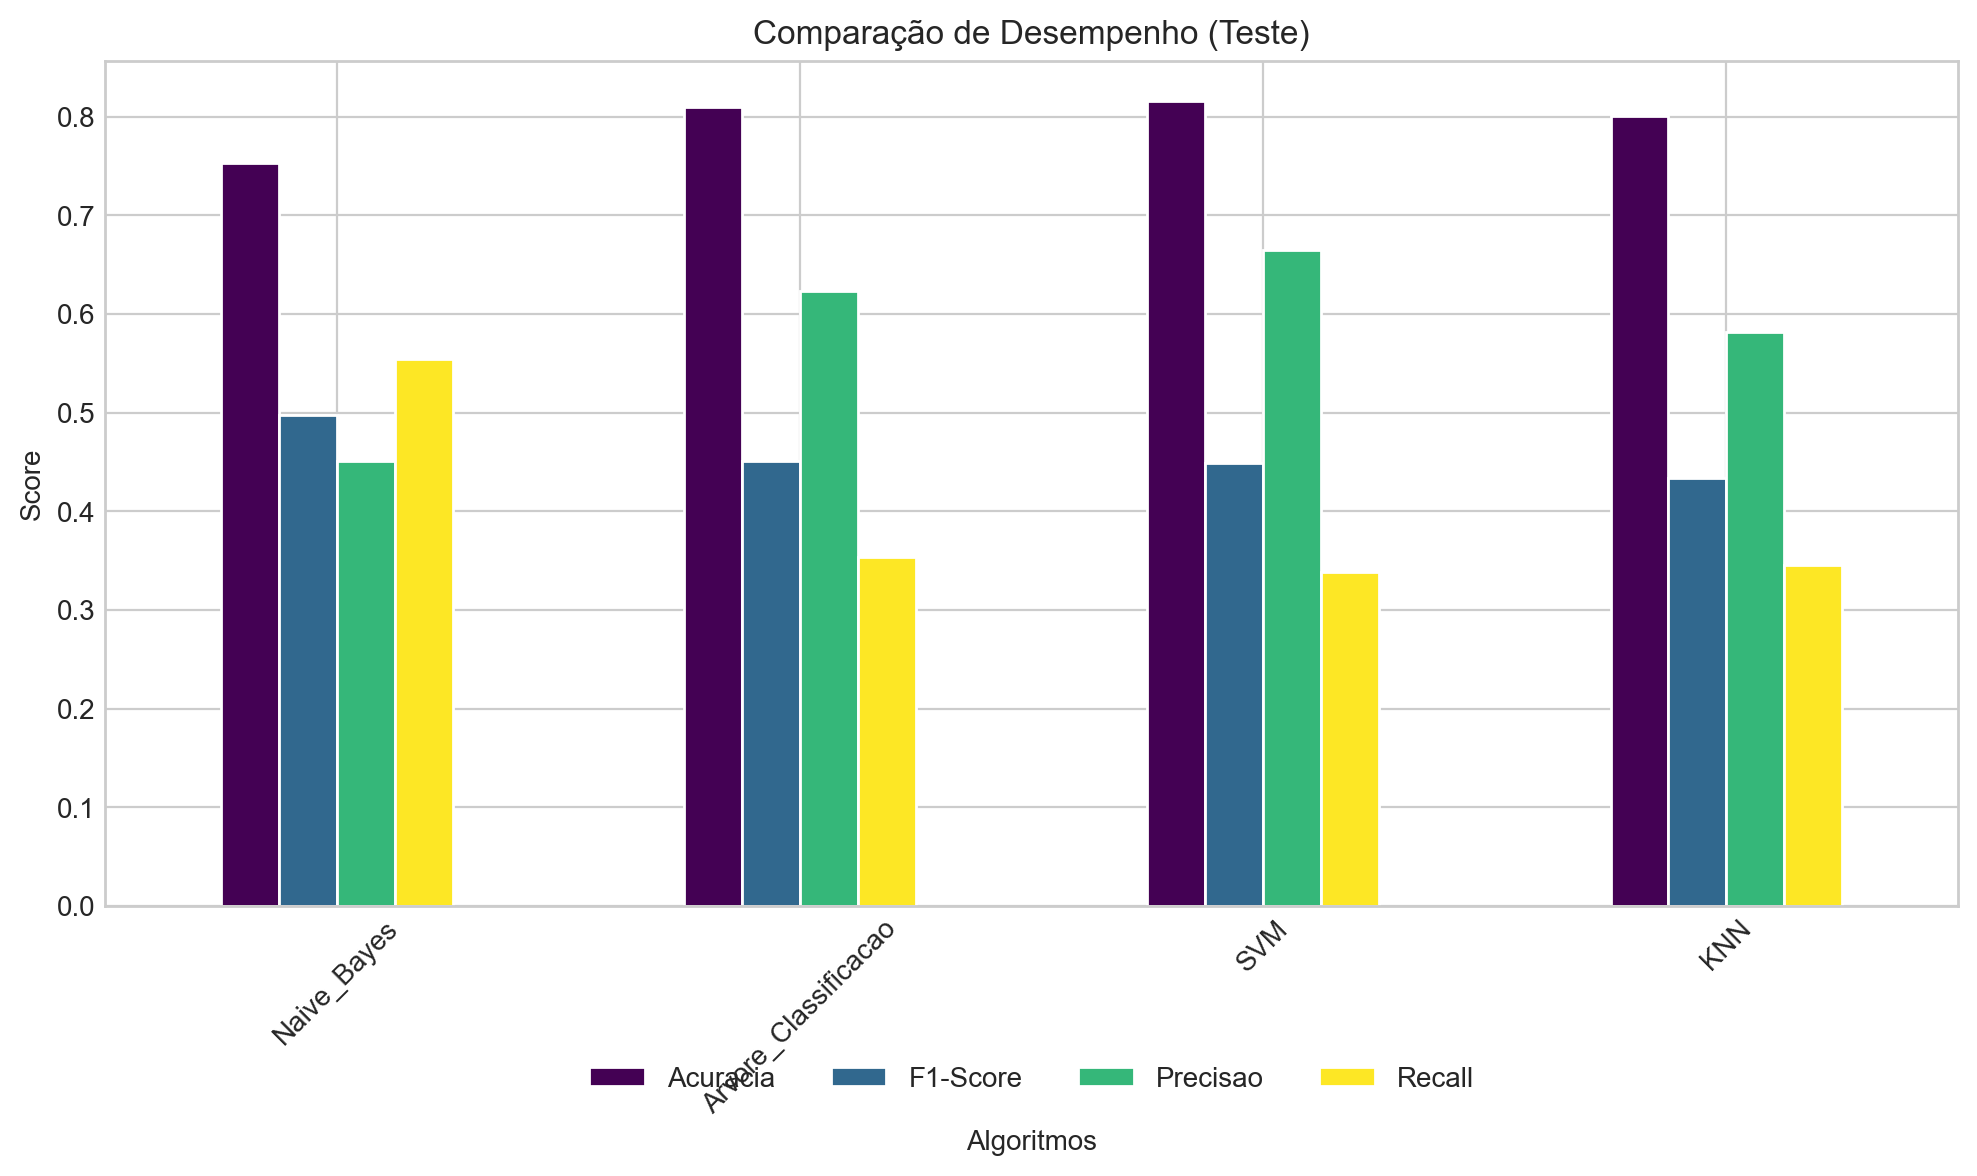

In [7]:
df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)
display(df_resultados)

df_plot = df_resultados.set_index('Modelo')[['Acuracia', 'F1-Score', 'Precisao', 'Recall']]
df_plot.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Comparação de Desempenho (Teste)')
plt.ylabel('Score'); plt.xlabel('Algoritmos'); plt.xticks(rotation=45)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4)
plt.tight_layout()
plt.show()

## 6. Exportação do Modelo Resultante

In [8]:
# Exportação
melhor_modelo_nome = df_resultados.iloc[0]['Modelo']
melhor_modelo = best_models[melhor_modelo_nome]
nome_arquivo = f'modelo_{melhor_modelo_nome}_inadimplencia.pkl'

with open(f"../models/{nome_arquivo}", 'wb') as f:
    joblib.dump(melhor_modelo, f)
print(f'Modelo "{melhor_modelo_nome}" exportado com sucesso como "{nome_arquivo}"')

Modelo "Naive_Bayes" exportado com sucesso como "modelo_Naive_Bayes_inadimplencia.pkl"
